#**QUESTÃO 2**

##**Item 1**
Se trata de uma distribuição binomial com um número muito grande de tentativas e uma chance muito pequena, que permite a aproximação por uma distribuição de poisson com λ = np = 1. Como λ é 1, temos o valor esperado de 1 ganhador por dia. É possível ter mais de 1 ganhador por dia, mas matematicamente falando é bem improvável, pois a chance de haverem mais de 6 ganhadores em um dia é 1 menos a CDF até 6, que resulta em uma chance de $10^{-5}$. Após essa análise, é possível concluir que aproximar por uma CDF de uma poisson é matematicamente correto.

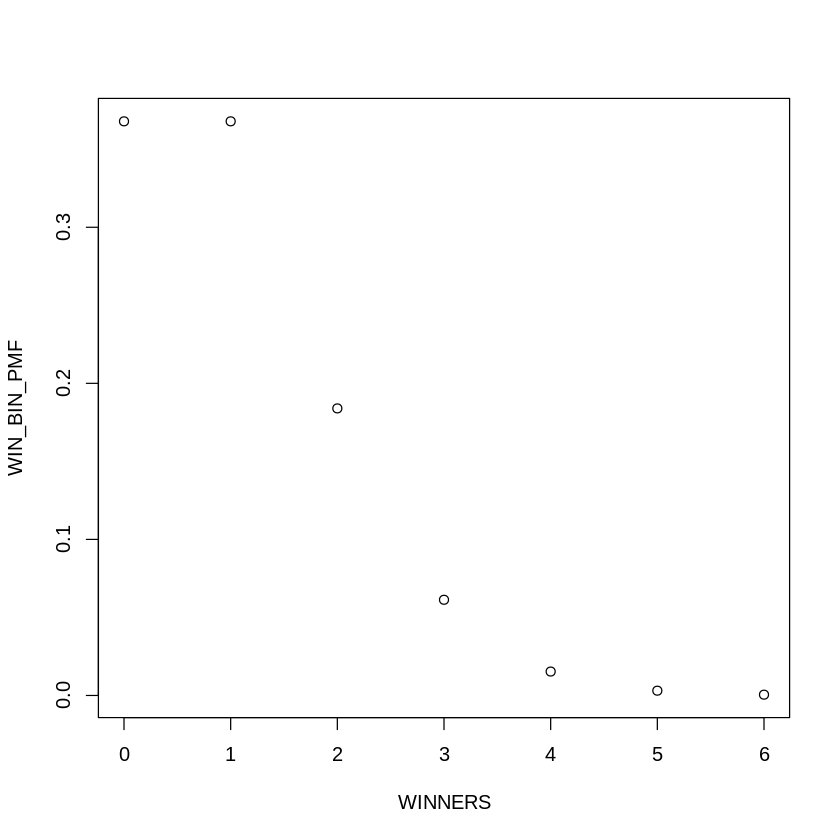

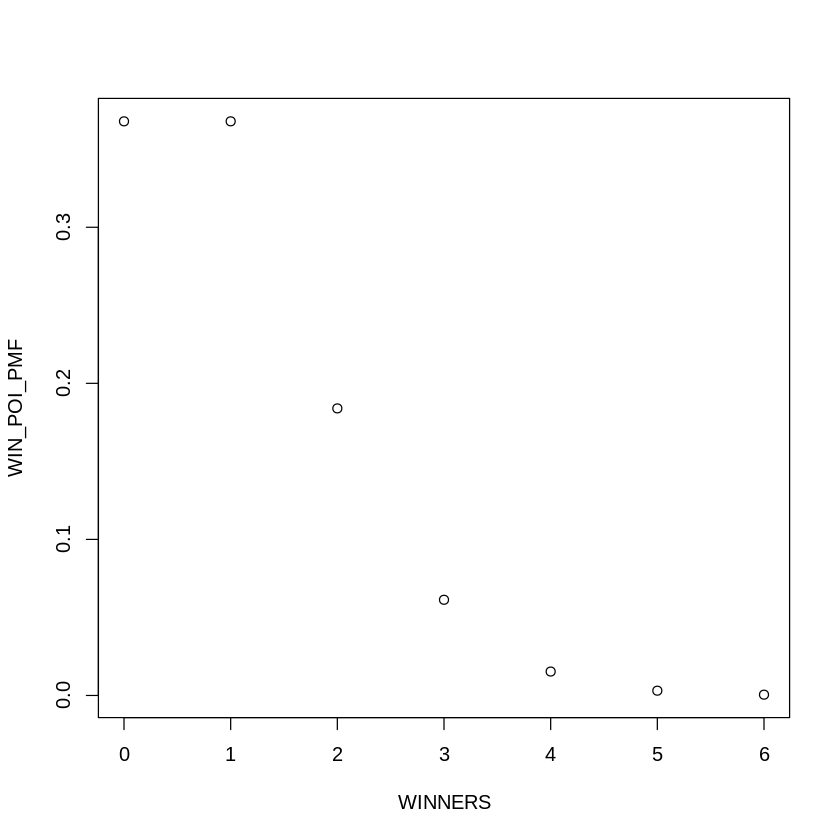

In [ ]:
WIN_BIN_CDF <- pbinom(6, 10000000, 1/10000000)
BIN_CHANCE <- 1 - WIN_BIN_CDF

WINNERS <- 0:6
WIN_BIN_PMF <- dbinom(WINNERS, 10^7, 10^-7)

WIN_POI_PMF <- dpois(WINNERS, 1)

plot(WINNERS, WIN_BIN_PMF)
plot(WINNERS, WIN_POI_PMF)

##**Item 2**
Binomial:
* E[X] = NP
* Var(X) = NP(1-P)

Poisson:
* E[X] = λ = Var(X)

Ao calcular a média e a variância usando ambas as distribuições fica claro a proximidade nos resultados de ambas, reforçando a validade da aproximação da binomial pela poisson.

In [ ]:
n <- 10^7
p <- 10^-7
lambda <- n*p

WIN_MEAN_BIN <- n*p
WIN_VAR_BIN <- n*p*(1-p)

WIN_MEAN_POI <- lambda
WIN_VAR_POI <- lambda

WIN_MEAN_BIN
WIN_VAR_BIN
WIN_MEAN_POI
WIN_VAR_POI

[1] 1

[1] 0.9999999

[1] 1

[1] 1

##**Item 3**
Para analisar a chance de ganhar em cenários onde há mais de um sorteado é possível usar a lei da probabilidade total, onde os resultados são somados com pesos, onde o peso de cada um é a chance de aquele espaço amostral ocorrer. No caso seria (Px(1) * $\frac{1}{1+1}$) + (Px(2) * $\frac{1}{1+2}$) + ...

In [ ]:
EXTRA_WIN <- seq(0,5,1)
EXTRA_WIN_PROB <- 1/(1+EXTRA_WIN)
EXTRA_WIN_POI <- dpois(EXTRA_WIN, 1)
chancee_sum <- EXTRA_WIN_POI*EXTRA_WIN_PROB
chancee <- sum(chancee_sum)

chancee

[1] 0.6320373

##**Item 4**
Ao gerar valores aleatórios que sigam a distribuição que representa a quantidade de vencedores, será possível observar uma média que se aproxima bastante da distribuição original.

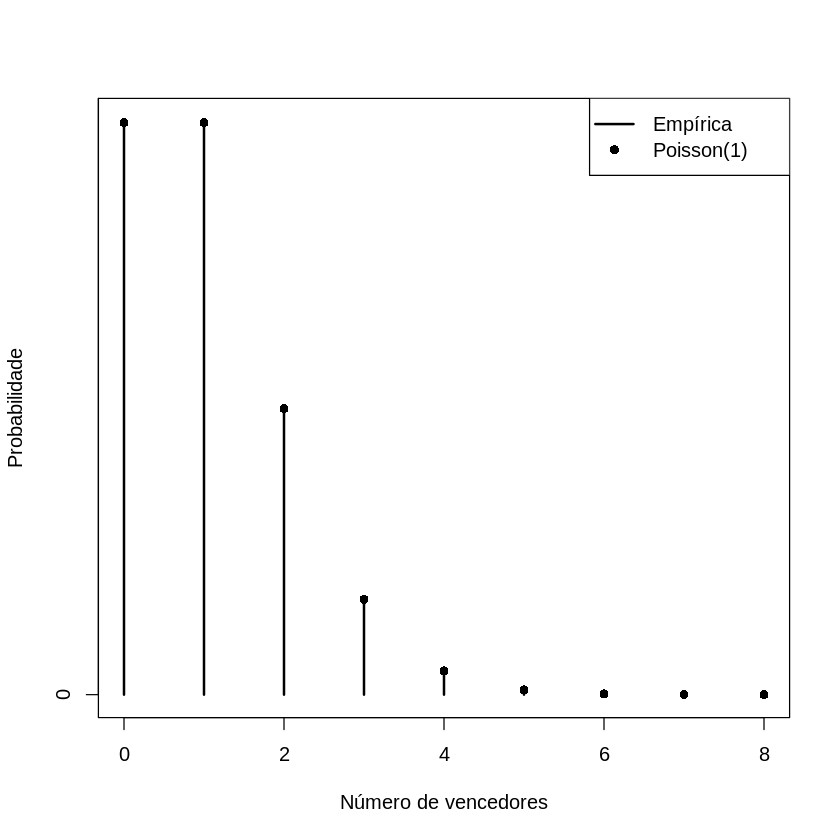

In [ ]:
WIN_POI_RAND <- rpois(100000, 1)

FREQ_EMP <- table(WIN_POI_RAND) / length(WIN_POI_RAND)

WINNERS <- as.numeric(names(FREQ_EMP))

WIN_POI_PMF <- dpois(WINNERS, 1)

plot(WINNERS, FREQ_EMP, type = "h", lwd = 2,
     ylim = c(0, max(FREQ_EMP, WIN_POI_PMF)),
     xlab = "Número de vencedores",
     ylab = "Probabilidade")
points(WINNERS, WIN_POI_PMF, pch = 16)
legend("topright",
       legend = c("Empírica", "Poisson(1)"),
       lwd = c(2, NA),
       pch = c(NA, 16))